<a href="https://colab.research.google.com/github/marcohinojosag/IA_MKTR/blob/jma-preproces/cod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importación de librerias y carga del dataset

In [324]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter

In [325]:
# Sets path
test_path = "aps_failure_test_set.csv"
train_path = "aps_failure_training_set.csv"

# Load the latest version
test = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  test_path,
)

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  train_path,
)

Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.
Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.


#1. Analisis del dataset train


In [326]:
# Muestra de los datos
print(df.head(5))

  class  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698     na  2130706438    280      0      0      0      0      0   
1   neg   33058     na           0     na      0      0      0      0      0   
2   neg   41040     na         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874     na        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [327]:
# Tamaño del dataset
print(df.shape)

(60000, 171)


In [328]:
# Se cambia la columna "class" a "clase"
df.rename(columns={'class': 'clase'}, inplace=True)

df.columns

Index(['clase', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000',
       'ag_000', 'ag_001', 'ag_002',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='object', length=171)

In [329]:
# Reemplazo de "na" por NaN
df = df.replace("na", np.nan)

print(df.head(5))

  clase  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698    NaN  2130706438    280      0      0      0      0      0   
1   neg   33058    NaN           0    NaN      0      0      0      0      0   
2   neg   41040    NaN         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874    NaN        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [330]:
# Separacion de negativos y positivos
df_neg = df[df['clase'] == 'neg']
df_pos = df[df['clase'] == 'pos']

In [331]:
# Cantidad de positivos y negativos del dataset
cant_neg = len(df_neg)
cant_pos = len(df_pos)
print(f"Negativos: {cant_neg}, Positivos: {cant_pos}")

Negativos: 59000, Positivos: 1000


# 2. Obtener columnas a eliminar por vacio

In [332]:
# Porcentaje de valores vacíos por columna
cv = df.isna().sum()/len(df)
cv_neg = df_neg.isna().sum()/cant_neg
cv_pos = df_pos.isna().sum()/cant_pos

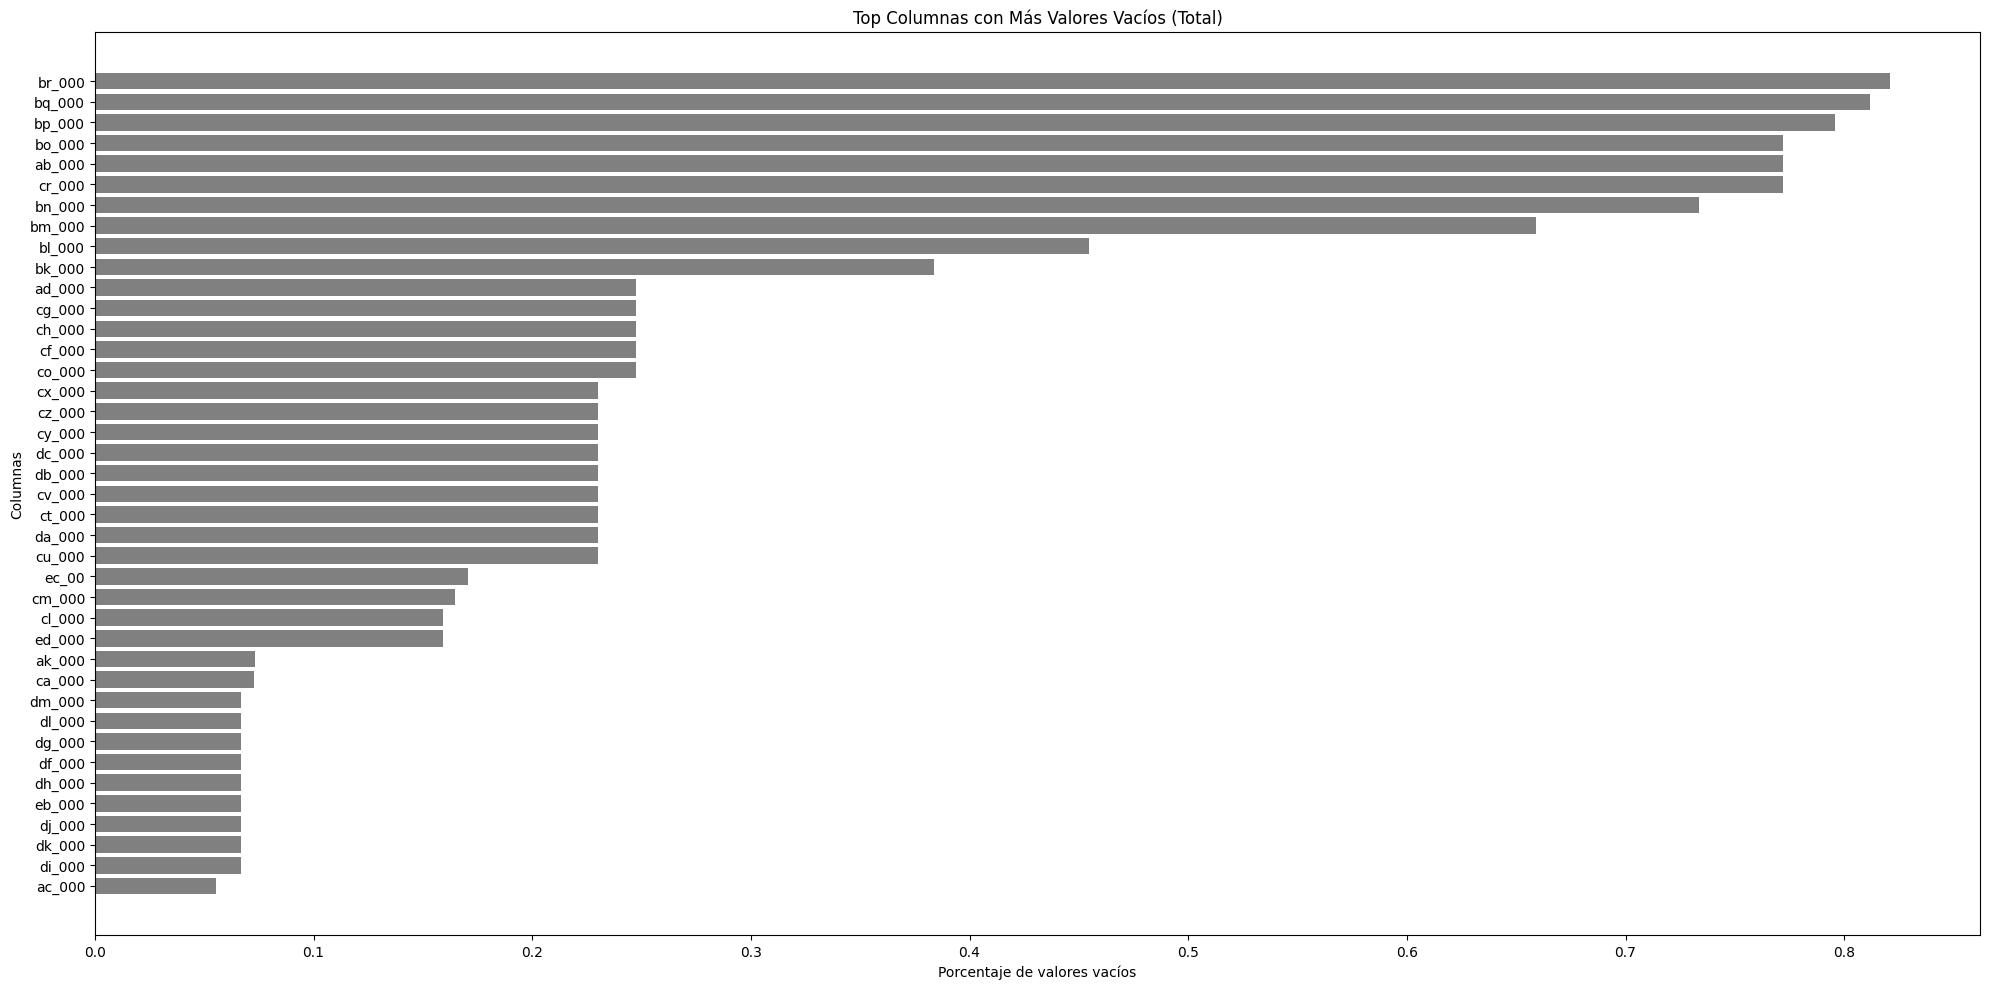

In [333]:
top = cv.sort_values(ascending=False).head(40)

plt.figure(figsize=(20, 10))
plt.barh(top.index[::-1], top.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Total)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

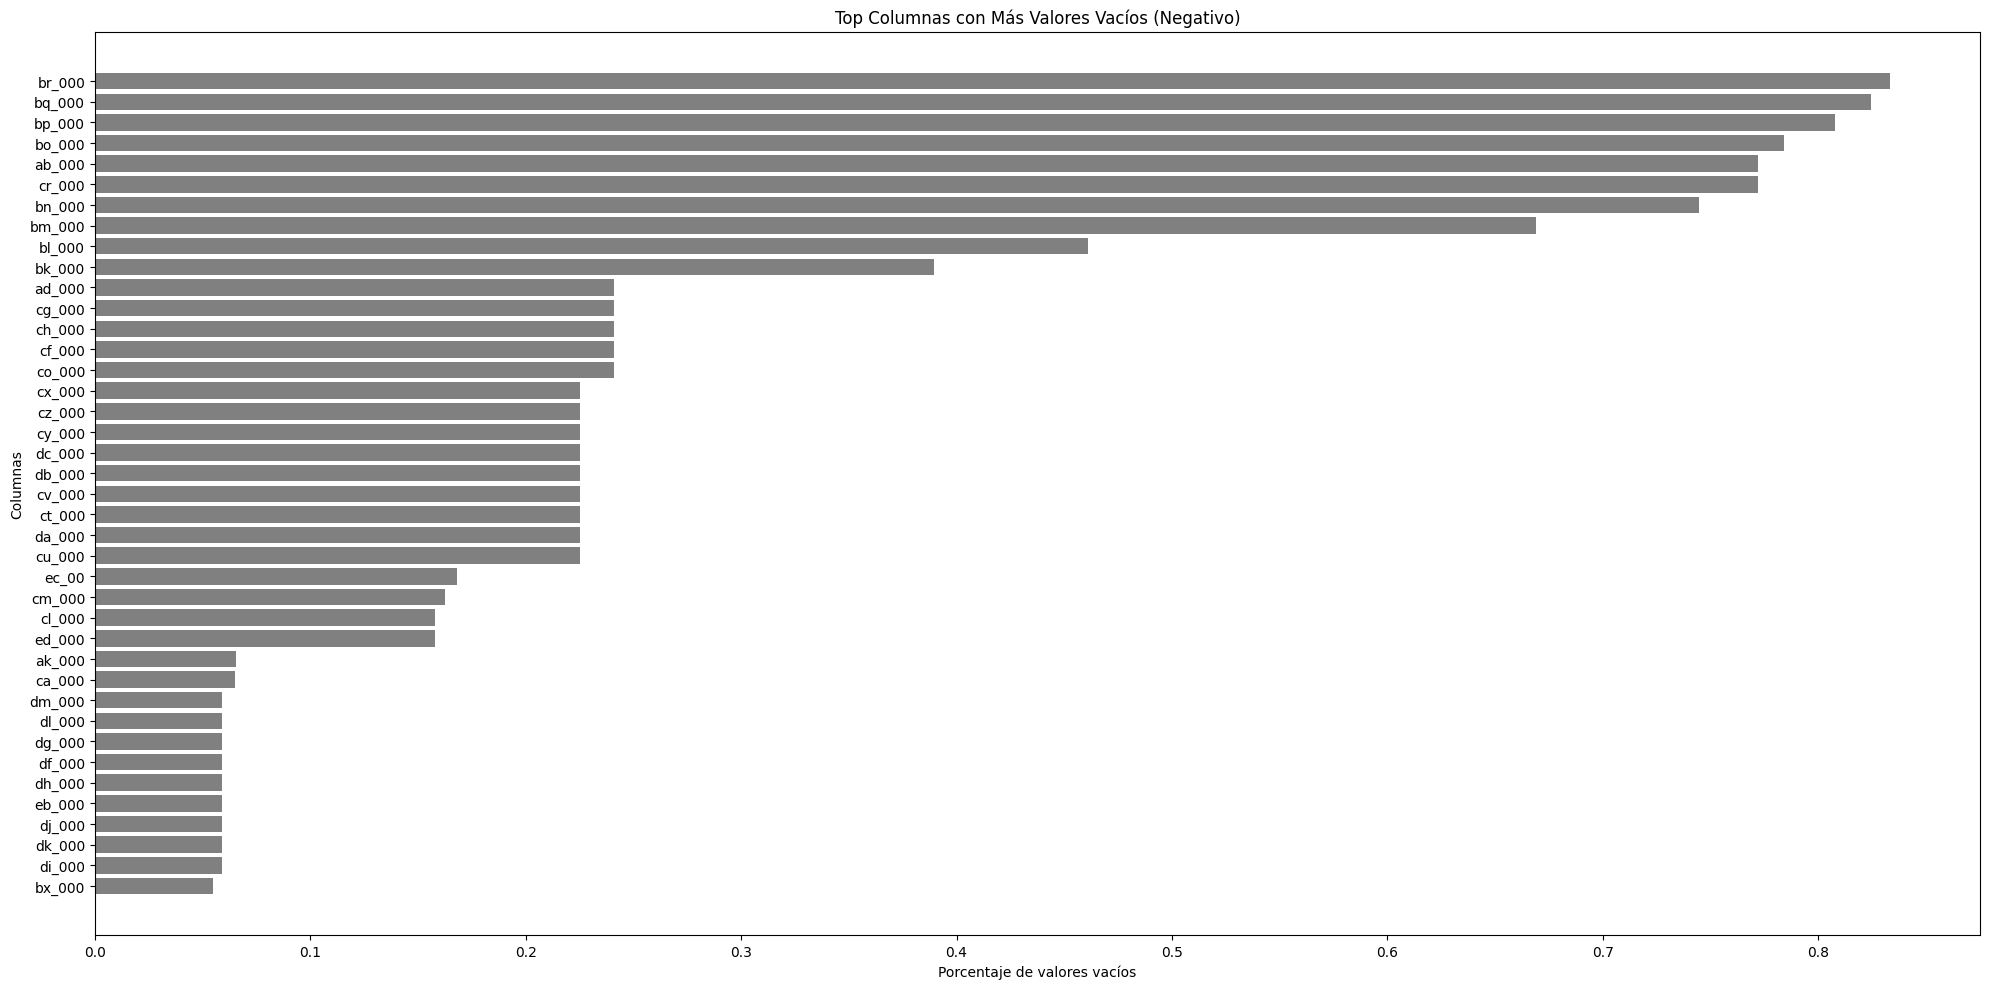

In [334]:
top_neg = cv_neg.sort_values(ascending=False).head(40)

plt.figure(figsize=(20, 10))
plt.barh(top_neg.index[::-1], top_neg.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Negativo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

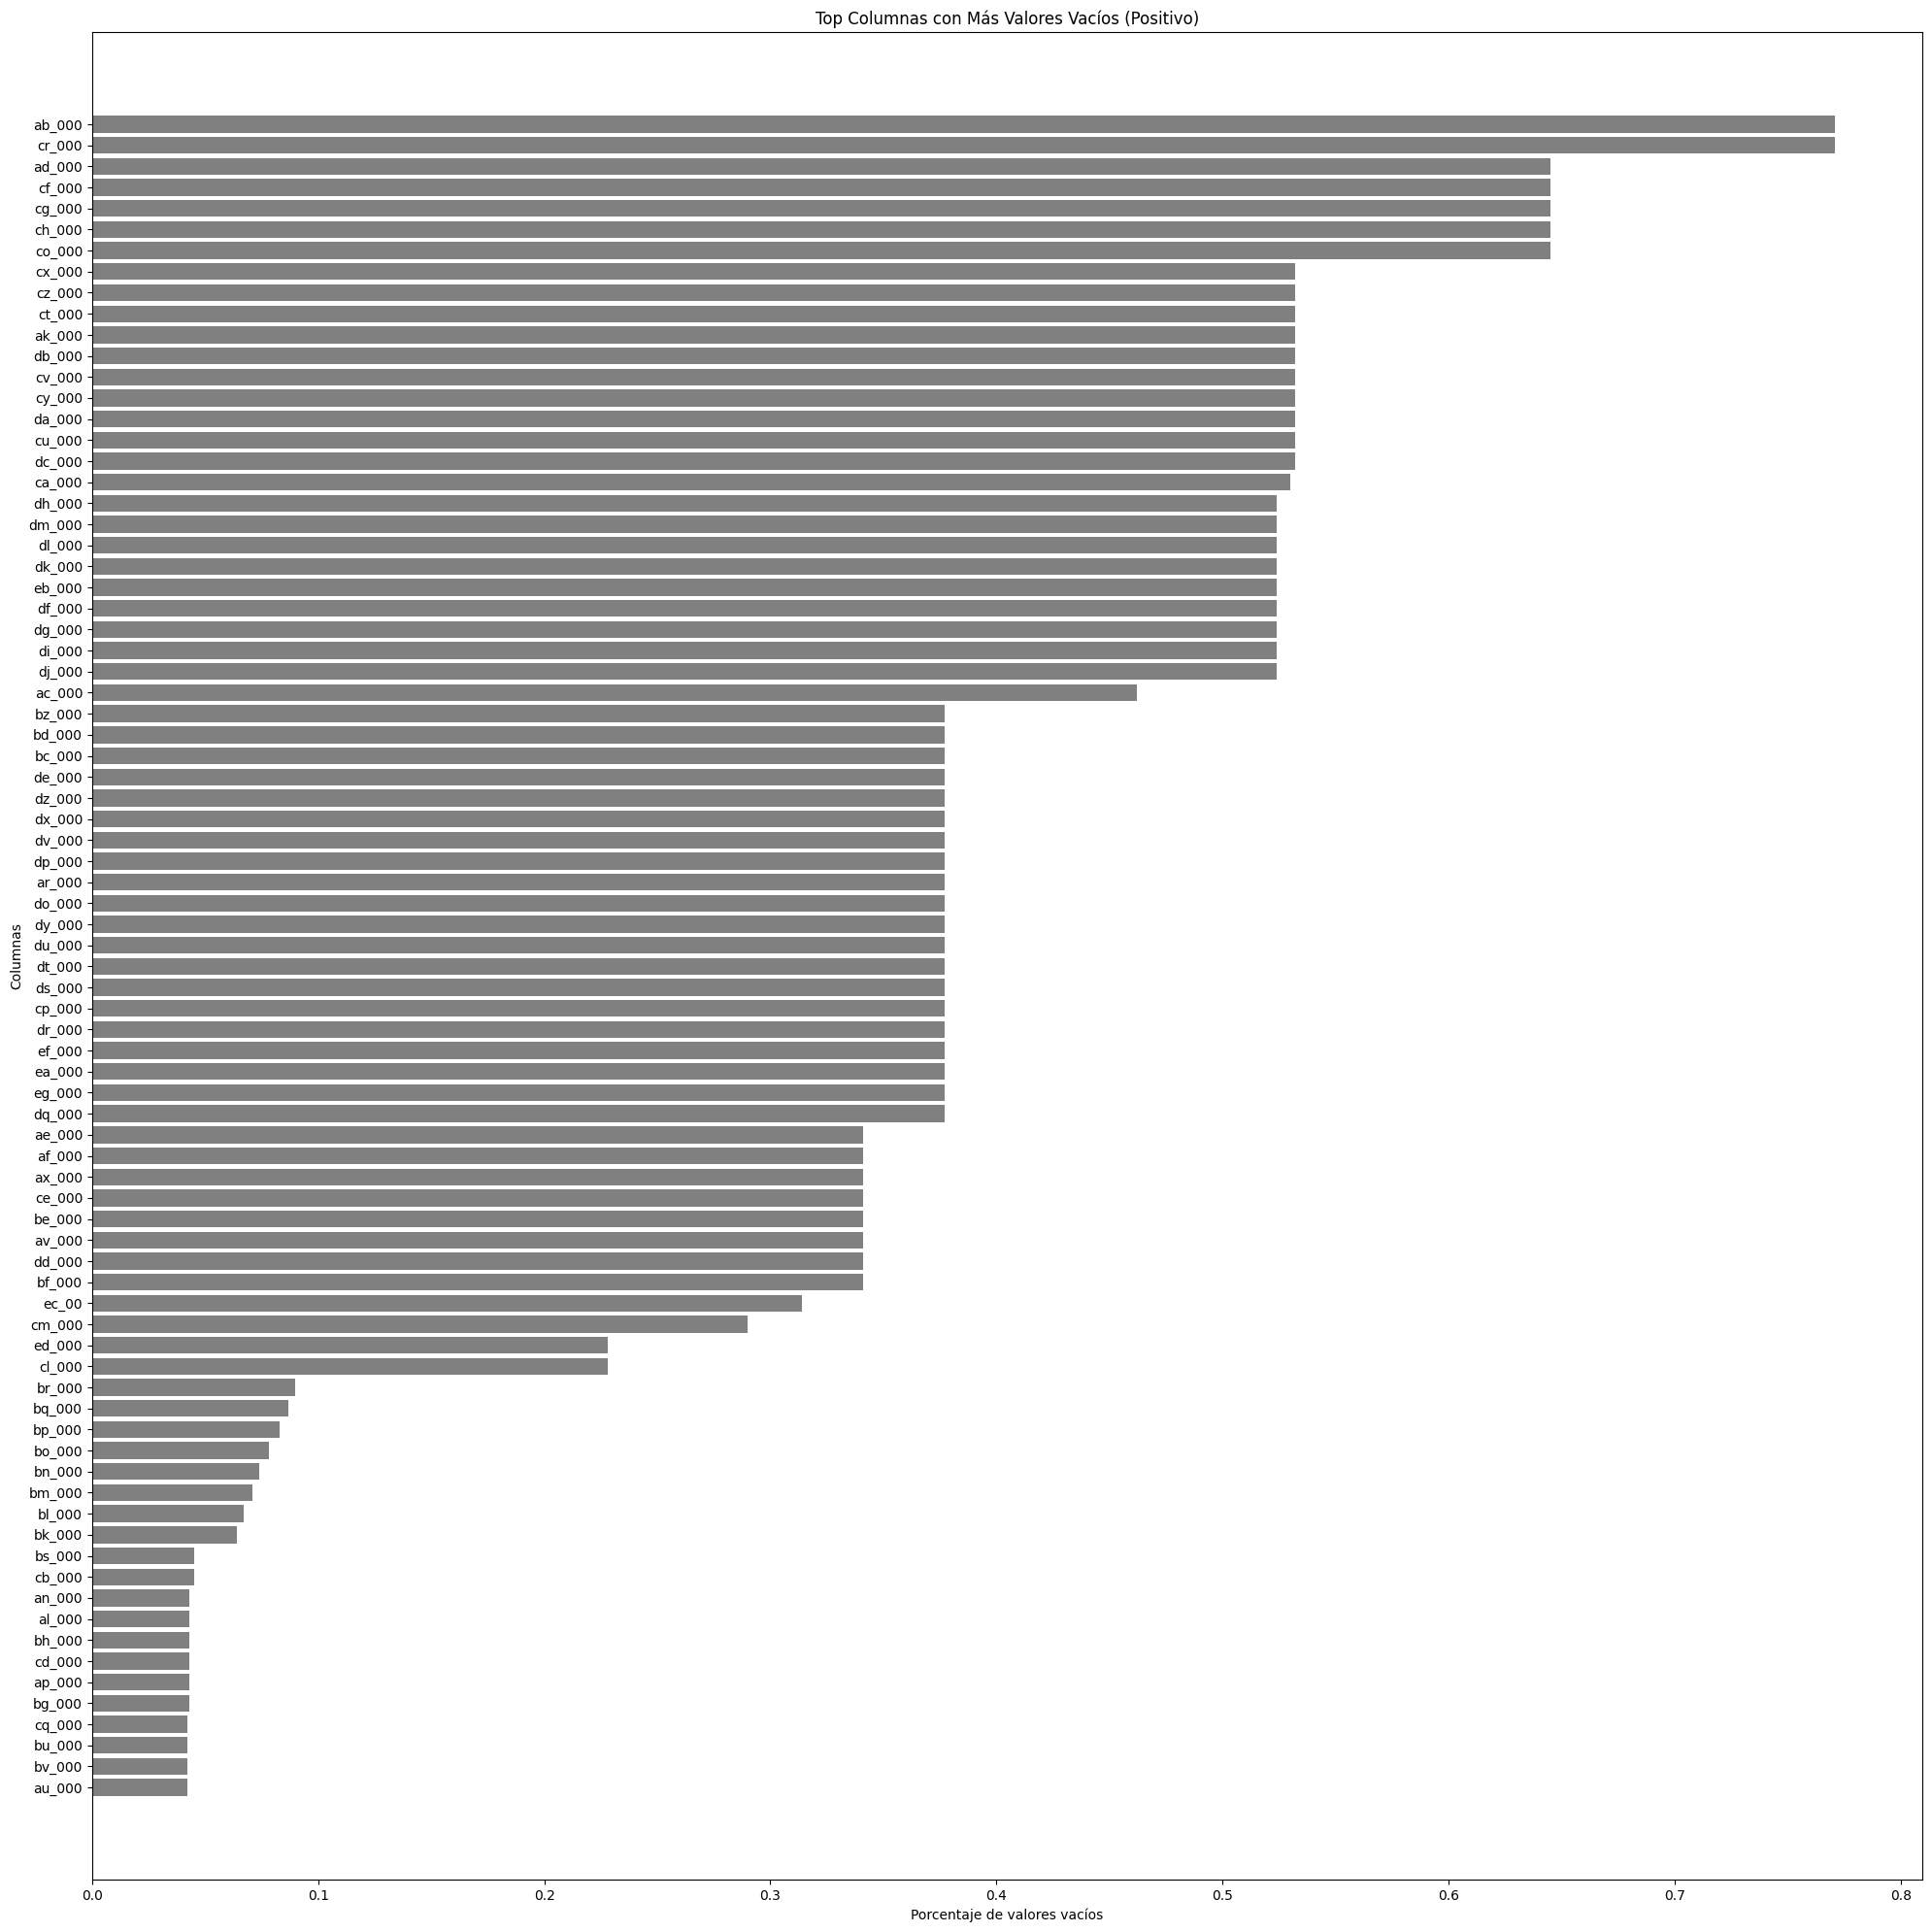

In [335]:
top_pos = cv_pos.sort_values(ascending=False).head(80)

plt.figure(figsize=(20, 20))
plt.barh(top_pos.index[::-1], top_pos.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top Columnas con Más Valores Vacíos (Positivo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

#3. Limpieza del dataset train

In [336]:
# Columnas con más de 10% de "na"
umbral_total = 0.1
cols_total_umbral = cv[cv > umbral_total].index.tolist()
print("Columnas totales:")
print(cols_total_umbral)

# Columnas con más de 10% de "na"
umbral_pos = 0.1
cols_pos_umbral = cv_pos[cv_pos > umbral_pos].index.tolist()
print("Columnas positivas:")
print(cols_pos_umbral)

# Columnas con más de 10% de "na"
umbral_neg = 0.1
cols_neg_umbral = cv_neg[cv_neg > umbral_neg].index.tolist()
print("Columnas negativas:")
print(cols_neg_umbral)

Columnas totales:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'ec_00', 'ed_000']
Columnas positivas:
['ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ak_000', 'ar_000', 'av_000', 'ax_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bz_000', 'ca_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cp_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'dd_000', 'de_000', 'df_000', 'dg_000', 'dh_000', 'di_000', 'dj_000', 'dk_000', 'dl_000', 'dm_000', 'do_000', 'dp_000', 'dq_000', 'dr_000', 'ds_000', 'dt_000', 'du_000', 'dv_000', 'dx_000', 'dy_000', 'dz_000', 'ea_000', 'eb_000', 'ec_00', 'ed_000', 'ef_000', 'eg_000']
Columnas negativas:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', '

In [337]:
# Elemento comunes de lista de columnas a eliminar
cols_eliminar = list(set(cols_total_umbral) & set(cols_pos_umbral) & set(cols_neg_umbral))

# Eliminar columnas
df_clean = df.drop(columns=cols_eliminar)

print(df_clean.head(5))

  clase  aa_000      ac_000 ae_000 af_000 ag_000 ag_001 ag_002 ag_003 ag_004  \
0   neg   76698  2130706438      0      0      0      0      0      0  37250   
1   neg   33058           0      0      0      0      0      0      0  18254   
2   neg   41040         228      0      0      0      0      0      0   1648   
3   neg      12          70      0     10      0      0      0    318   2212   
4   neg   60874        1368      0      0      0      0      0      0  43752   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [338]:
# Cambiar negativos a 0 y positivos a 1
df_clean["clase"] = df_clean["clase"].map({"neg": 0, "pos": 1})

print(df_clean.head(5))

   clase  aa_000      ac_000 ae_000 af_000 ag_000 ag_001 ag_002 ag_003 ag_004  \
0      0   76698  2130706438      0      0      0      0      0      0  37250   
1      0   33058           0      0      0      0      0      0      0  18254   
2      0   41040         228      0      0      0      0      0      0   1648   
3      0      12          70      0     10      0      0      0    318   2212   
4      0   60874        1368      0      0      0      0      0      0  43752   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1   

In [339]:
# Cambiar tipo de dato
df_clean = df_clean.astype(float)

print(df_clean.head(5))

   clase   aa_000        ac_000  ae_000  af_000  ag_000  ag_001  ag_002  \
0    0.0  76698.0  2.130706e+09     0.0     0.0     0.0     0.0     0.0   
1    0.0  33058.0  0.000000e+00     0.0     0.0     0.0     0.0     0.0   
2    0.0  41040.0  2.280000e+02     0.0     0.0     0.0     0.0     0.0   
3    0.0     12.0  7.000000e+01     0.0    10.0     0.0     0.0     0.0   
4    0.0  60874.0  1.368000e+03     0.0     0.0     0.0     0.0     0.0   

   ag_003   ag_004  ...     ee_002    ee_003    ee_004    ee_005    ee_006  \
0     0.0  37250.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0   
1     0.0  18254.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   
2     0.0   1648.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0   
3   318.0   2212.0  ...      240.0      46.0      58.0      44.0      10.0   
4     0.0  43752.0  ...   622012.0  229790.0  405298.0  347188.0  286954.0   

     ee_007    ee_008  ee_009  ef_000  eg_000  
0  157956.0   73224.0     0.0   

In [340]:
# Manejar los valores nulos (NaN)
from sklearn.impute import SimpleImputer

df_imputado = df_clean.copy()

imputer = SimpleImputer(strategy="median") # Se pude usar 'mean:12100', 'median:11440', 'most_frequent:11980'
df_clean = pd.DataFrame(imputer.fit_transform(df_imputado), columns=df_imputado.columns)

print(df_clean.head(5))

   clase   aa_000        ac_000  ae_000  af_000  ag_000  ag_001  ag_002  \
0    0.0  76698.0  2.130706e+09     0.0     0.0     0.0     0.0     0.0   
1    0.0  33058.0  0.000000e+00     0.0     0.0     0.0     0.0     0.0   
2    0.0  41040.0  2.280000e+02     0.0     0.0     0.0     0.0     0.0   
3    0.0     12.0  7.000000e+01     0.0    10.0     0.0     0.0     0.0   
4    0.0  60874.0  1.368000e+03     0.0     0.0     0.0     0.0     0.0   

   ag_003   ag_004  ...     ee_002    ee_003    ee_004    ee_005    ee_006  \
0     0.0  37250.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0   
1     0.0  18254.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   
2     0.0   1648.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0   
3   318.0   2212.0  ...      240.0      46.0      58.0      44.0      10.0   
4     0.0  43752.0  ...   622012.0  229790.0  405298.0  347188.0  286954.0   

     ee_007    ee_008  ee_009  ef_000  eg_000  
0  157956.0   73224.0     0.0   

In [341]:
# Normalizar
from sklearn.preprocessing import MinMaxScaler, StandardScaler
df_norm = df_clean.copy()

scaler = MinMaxScaler()
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

df_clean[num_cols] = scaler.fit_transform(df_norm[num_cols])

print(df_clean.head(5))

   clase    aa_000        ac_000  ae_000    af_000  ag_000  ag_001  ag_002  \
0    0.0  0.027925  9.999998e-01     0.0  0.000000     0.0     0.0     0.0   
1    0.0  0.012036  0.000000e+00     0.0  0.000000     0.0     0.0     0.0   
2    0.0  0.014942  1.070067e-07     0.0  0.000000     0.0     0.0     0.0   
3    0.0  0.000004  3.285295e-08     0.0  0.000498     0.0     0.0     0.0   
4    0.0  0.022164  6.420405e-07     0.0  0.000000     0.0     0.0     0.0   

     ag_003    ag_004  ...    ee_002    ee_003        ee_004        ee_005  \
0  0.000000  0.000163  ...  0.015918  0.013067  7.421784e-03  8.179508e-03   
1  0.000000  0.000080  ...  0.005407  0.004716  3.019031e-03  4.272917e-03   
2  0.000000  0.000007  ...  0.003559  0.004232  4.364196e-03  7.130884e-03   
3  0.000005  0.000010  ...  0.000003  0.000001  5.970003e-07  7.660803e-07   
4  0.000000  0.000191  ...  0.007981  0.006086  4.171776e-03  6.044861e-03   

         ee_006    ee_007    ee_008    ee_009    ef_000    eg_

In [342]:
# Separacion de negativos y positivos
df_clean_neg = df_clean[df_clean['clase'] == 0]
df_clean_pos = df_clean[df_clean['clase'] == 1]

print(f"N° negativos orginales: {len(df_clean_neg)}, N° positivos originales: {len(df_clean_pos)}")

N° negativos orginales: 59000, N° positivos originales: 1000


In [343]:
# Se eliminan algunas filas de los negativos (undersampling)
# Muestra mejor precio con ratio menor

from sklearn.utils import resample

ratio = 1

df_neg_down = resample(df_clean_neg,
                       replace=False,     # sin reemplazo
                       n_samples= ratio*len(df_pos),
                       random_state=42)

# Nuevo dataset balanceado
df_clean = pd.concat([df_clean_pos, df_neg_down])

print(f"N° negativos balanceados: {len(df_clean[df_clean['clase'] == 0])}, N° positivos balanceados: {len(df_clean[df_clean['clase'] == 1])}")

N° negativos balanceados: 1000, N° positivos balanceados: 1000


In [344]:
# Se agregan algunas filas de los positivos (oversampling)
# 133.27 segundos para entrenamiento

# from sklearn.utils import resample

# df_pos_up  = resample(df_clean_pos,
#                        replace=True,     # con reemplazo
#                        n_samples=len(df_pos),
#                        random_state=42)

# # Nuevo dataset balanceado
# df_clean = pd.concat([df_pos_up, df_clean_neg])

# print(f"N° negativos balanceados: {len(df_clean[df_clean['clase'] == 0])}, N° positivos balanceados: {len(df_clean[df_clean['clase'] == 1])}")

#4. Procesar dataset test

In [345]:
# Tamaño del dataset
print(test.shape)

(16000, 171)


In [346]:

test.rename(columns={'class': 'clase'}, inplace=True) # Cambiar titulo de columna

test_clean = test.replace("na", np.nan) # Cambiar 'na' a NaN

test_clean = test_clean.drop(columns=cols_eliminar) # Elmimina las mismas columnas que en train

test_clean["clase"] = test_clean["clase"].map({"neg": 0, "pos": 1}) # Cambiar 'neg' a 0 y 'pos' a 1

test_clean = test_clean.astype(float) # Cambia el tipo de dato

test_clean = pd.DataFrame(imputer.transform(test_clean), columns=test_clean.columns) # Tratar los vacios con la configuracion en train

test_clean[num_cols] = scaler.transform(test_clean[num_cols]) # Normalizar con la configuracion en train

print(test_clean.head(5))

   clase    aa_000        ac_000  ae_000  af_000  ag_000  ag_001  ag_002  \
0    0.0  0.000022  9.386557e-09     0.0     0.0     0.0     0.0     0.0   
1    0.0  0.000030  3.191429e-08     0.0     0.0     0.0     0.0     0.0   
2    0.0  0.024031  9.949750e-08     0.0     0.0     0.0     0.0     0.0   
3    0.0  0.021778  4.740211e-07     0.0     0.0     0.0     0.0     0.0   
4    0.0  0.000660  7.321514e-08     0.0     0.0     0.0     0.0     0.0   

     ag_003        ag_004  ...    ee_002    ee_003    ee_004    ee_005  \
0  0.000042  2.069654e-05  ...  0.000014  0.000004  0.000004  0.000011   
1  0.000000  3.268794e-06  ...  0.000014  0.000007  0.000017  0.000002   
2  0.003146  5.936864e-03  ...  0.006353  0.010074  0.004530  0.004693   
3  0.000000  5.415448e-04  ...  0.006939  0.006443  0.004975  0.008450   
4  0.000000  3.146433e-07  ...  0.000098  0.000110  0.000190  0.000867   

     ee_006        ee_007    ee_008    ee_009  ef_000  eg_000  
0  0.000002  7.359084e-07  0.00000

#5. Entrenamiento del modelo randomForest

In [362]:
x_train = df_clean.drop(columns=['clase'])
y_train = df_clean['clase']

x_test  = test_clean.drop(columns=['clase'])
y_test  = test_clean['clase']

In [363]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model = RandomForestClassifier(n_estimators=100)

# Entrenamiento del modelo
model.fit(x_train, y_train)
print("Entrenamiento completo")

Entrenamiento completo


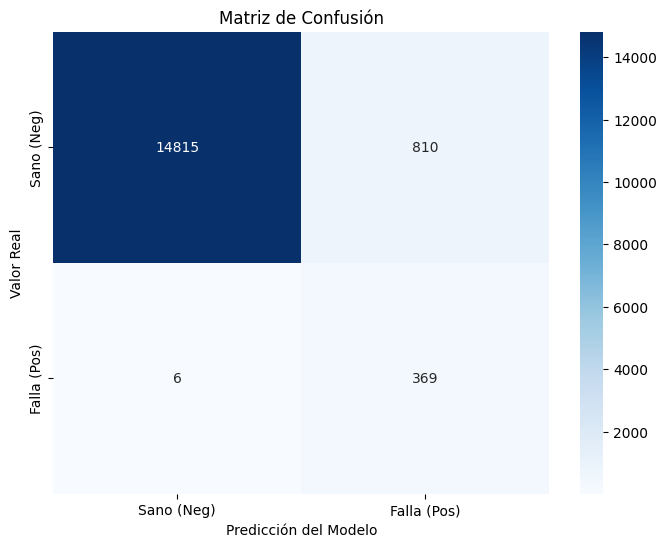

In [364]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Obtencion de predicciones
y_pred = model.predict(x_test)

# Calculo y grafica de la matriz de confusion
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (Neg)', 'Falla (Pos)'],
            yticklabels=['Sano (Neg)', 'Falla (Pos)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

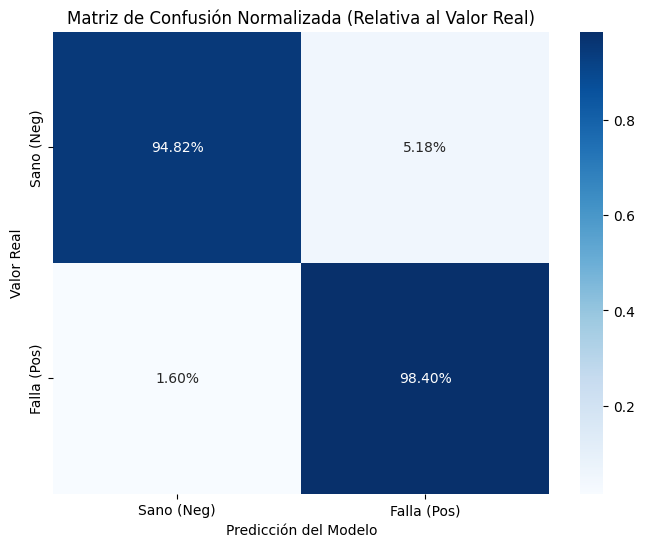

In [365]:
# matriz normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Sano (Neg)', 'Falla (Pos)'],
            yticklabels=['Sano (Neg)', 'Falla (Pos)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Normalizada (Relativa al Valor Real)')
plt.show()

In [366]:
# Calculo del costo total basado en la matriz de confusión
costo_1 = 10
costo_2 = 500
costo_total = (fp * costo_1) + (fn * costo_2)

In [367]:
print("Resultados:")
print(f"Verdaderos Negativos (VN): {tn}")
print(f"Falsos Positivos (FP) - Costo 1: {fp}")
print(f"Falsos Negativos (FN) - Costo 2: {fn}")
print(f"Verdaderos Positivos (VP): {tp}")
print("")
print(f"Costo Total de Errores: ${costo_total:,.2f}")

Resultados:
Verdaderos Negativos (VN): 14815
Falsos Positivos (FP) - Costo 1: 810
Falsos Negativos (FN) - Costo 2: 6
Verdaderos Positivos (VP): 369

Costo Total de Errores: $11,100.00


# Tuneado

In [353]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, confusion_matrix
import numpy as np

def total_cost_func(y_true, y_pred):
    """
    Calcula el costo total basado en la matriz de confusión.
    Un costo menor es mejor.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    costo = (fp * 10) + (fn * 500)
    return costo

cost_scorer = make_scorer(total_cost_func, greater_is_better=False)

param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [{0: 10, 1: 500}, {0: 10, 1: 550}, {0: 12, 1: 500}, {0: 10, 1: 600}]
}

rf_base = RandomForestClassifier(random_state=100)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring=cost_scorer # puntaje personalizado
)

# Inicio de busqueda
random_search.fit(x_train, y_train)
print("Ajuste completado")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Ajuste completado


In [354]:
# Mejores resultados
print("Resultados del Tunning")
print(f"Mejor Costo (con los datos de entrenamiento): ${-random_search.best_score_:,.2f}")
print("Mejores Hiperparámetros encontrados:")
print(random_search.best_params_)

Resultados del Tunning
Mejor Costo (con los datos de entrenamiento): $3,760.00
Mejores Hiperparámetros encontrados:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None, 'class_weight': {0: 10, 1: 550}}


In [355]:
# Resultados
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(x_test)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_tuned, fp_tuned, fn_tuned, tp_tuned = cm_tuned.ravel()

costo_1 = 10
costo_2 = 500
costo_total_tuned = (fp_tuned * costo_1) + (fn_tuned * costo_2)

print("--- Métricas de Costo (Modelo Tuneado) ---")
print(f"Falsos Positivos (FP): {fp_tuned}")
print(f"Falsos Negativos (FN): {fn_tuned}")
print("--------------------------------------------------")
print(f"Costo Total de Errores: ${costo_total_tuned:,.2f}")
print("--------------------------------------------------\n")

print(classification_report(y_test, y_pred_tuned, target_names=['Sano (clase 0)', 'Falla (clase 1)']))

--- Métricas de Costo (Modelo Tuneado) ---
Falsos Positivos (FP): 1248
Falsos Negativos (FN): 4
--------------------------------------------------
Costo Total de Errores: $14,480.00
--------------------------------------------------

                 precision    recall  f1-score   support

 Sano (clase 0)       1.00      0.92      0.96     15625
Falla (clase 1)       0.23      0.99      0.37       375

       accuracy                           0.92     16000
      macro avg       0.61      0.95      0.67     16000
   weighted avg       0.98      0.92      0.94     16000



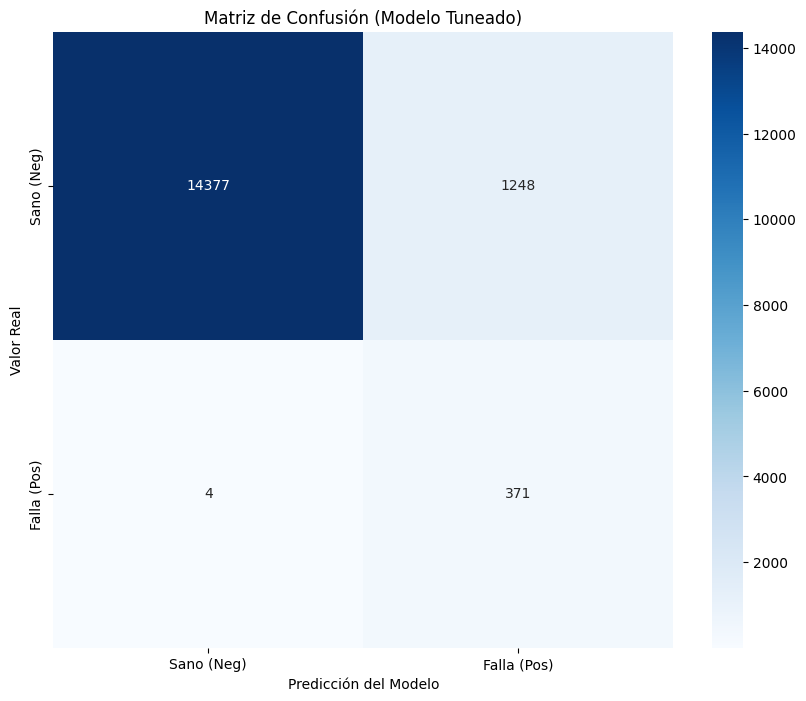

In [356]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (Neg)', 'Falla (Pos)'],
            yticklabels=['Sano (Neg)', 'Falla (Pos)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Modelo Tuneado)')
plt.show()

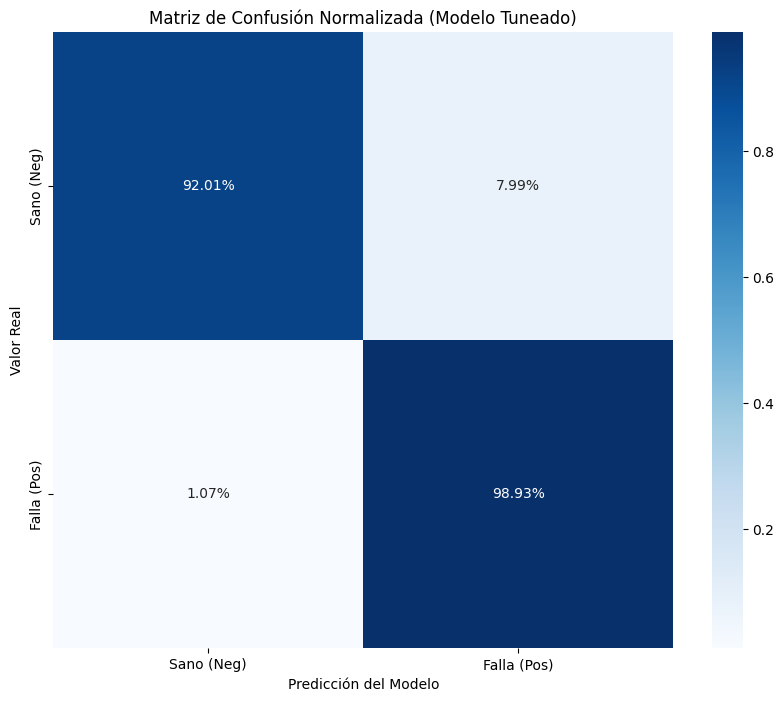

In [357]:
cm_normalized_tuned = cm_tuned.astype('float') / cm_tuned.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized_tuned, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Sano (Neg)', 'Falla (Pos)'],
            yticklabels=['Sano (Neg)', 'Falla (Pos)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Normalizada (Modelo Tuneado)')
plt.show()

# Seleccion de el mejor umbral

--- Optimización de Umbral ---
Costo Mínimo encontrado: $12,960.00
Mejor Umbral de Decisión: 0.67


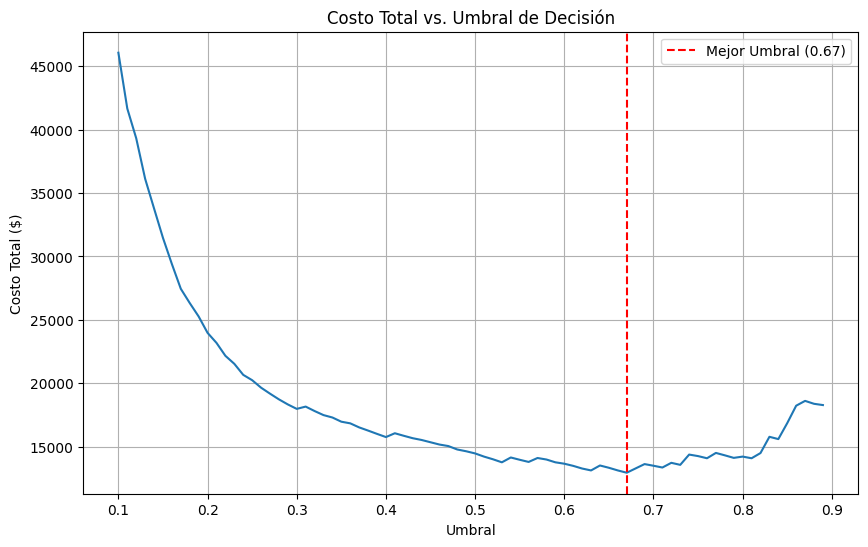

In [358]:
y_pred_probs = best_model.predict_proba(x_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
costs = []
best_threshold = 0.5
min_cost = float('inf')

for threshold in thresholds:

    y_pred_threshold = (y_pred_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    current_cost = (fp * 10) + (fn * 500)
    costs.append(current_cost)

    if current_cost < min_cost:
        min_cost = current_cost
        best_threshold = threshold

print(f"--- Optimización de Umbral ---")
print(f"Costo Mínimo encontrado: ${min_cost:,.2f}")
print(f"Mejor Umbral de Decisión: {best_threshold:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs)
plt.title('Costo Total vs. Umbral de Decisión')
plt.xlabel('Umbral')
plt.ylabel('Costo Total ($)')
plt.grid(True)
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Mejor Umbral ({best_threshold:.2f})')
plt.legend()
plt.show()

In [359]:
y_pred_final = (y_pred_probs >= best_threshold).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
tn_final, fp_final, fn_final, tp_final = cm_final.ravel()
costo_1 = 10
costo_2 = 500
costo_total_final = (fp_final * costo_1) + (fn_final * costo_2)

print("--- Resultados con Umbral Optimizado (0.66) ---")
print(f"Falsos Positivos (FP): {fp_final}")
print(f"Falsos Negativos (FN): {fn_final}")
print("--------------------------------------------------")
print(f"Costo Total Final: ${costo_total_final:,.2f}")
print("--------------------------------------------------\n")

print("\n--- Reporte de Clasificación (Umbral 0.66) ---\n")
print(classification_report(y_test, y_pred_final, target_names=['Sano (clase 0)', 'Falla (clase 1)']))

--- Resultados con Umbral Optimizado (0.66) ---
Falsos Positivos (FP): 946
Falsos Negativos (FN): 7
--------------------------------------------------
Costo Total Final: $12,960.00
--------------------------------------------------


--- Reporte de Clasificación (Umbral 0.66) ---

                 precision    recall  f1-score   support

 Sano (clase 0)       1.00      0.94      0.97     15625
Falla (clase 1)       0.28      0.98      0.44       375

       accuracy                           0.94     16000
      macro avg       0.64      0.96      0.70     16000
   weighted avg       0.98      0.94      0.96     16000



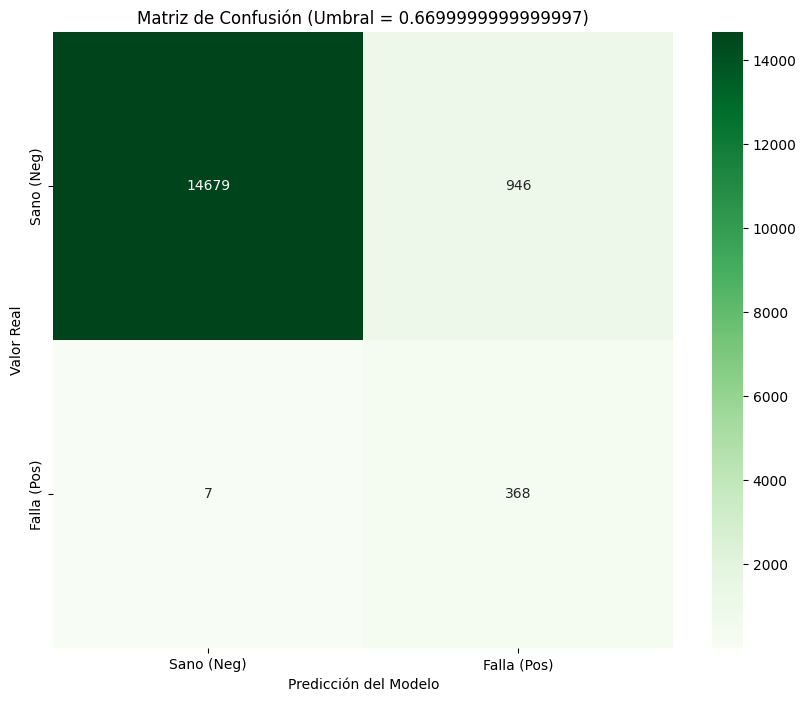

In [360]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sano (Neg)', 'Falla (Pos)'],
            yticklabels=['Sano (Neg)', 'Falla (Pos)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title(f'Matriz de Confusión (Umbral = {best_threshold})')
plt.show()

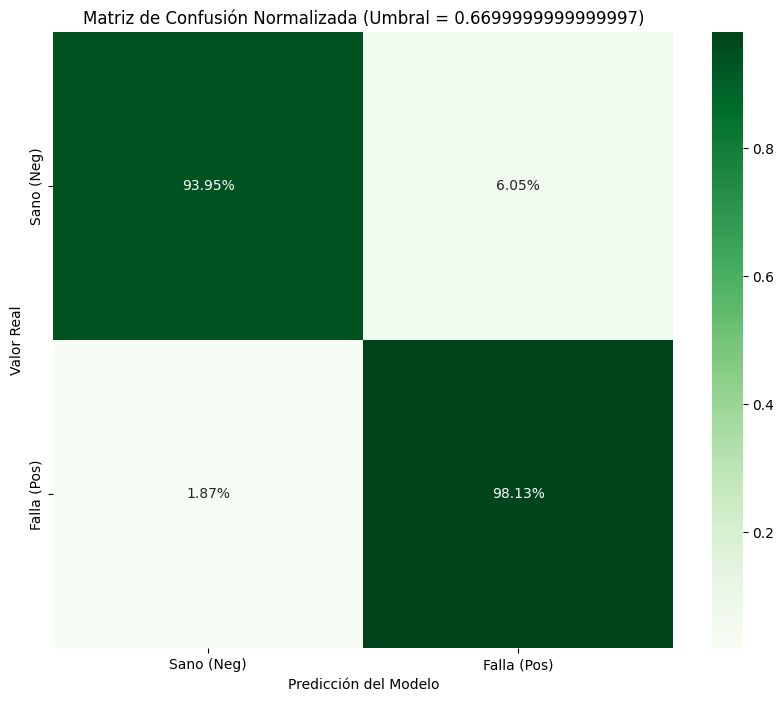

In [361]:
cm_final_normalized = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_final_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Sano (Neg)', 'Falla (Pos)'],
            yticklabels=['Sano (Neg)', 'Falla (Pos)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title(f'Matriz de Confusión Normalizada (Umbral = {best_threshold})')
plt.show()